### Sadržaj

- [Uvod](#uvod)
- [1D problem](#1d-problem)
- [2D problem](#2d-problem)
- [Zaključak](#zaključak)


***

### Uvod

Cilj ovog notebook-a je da demonstrira korišćenje **Physics-Informed Neural Network (PINN)** pristupa za rekonstrukciju vertikalnog profila temperature $T(x, z)$ i pritiska $P(x, z)$ u atmosferi uz dostupnim podacima za temperaturu $T_{\mathrm{data}}(x, z)$.

Zadatak mreže je da istovremeno:
1. Reprodukuje poznati temperaturni profil $T_{\mathrm{data}}(x, z)$ u domenu.
2. Uz prethodnu pretpostavku da u podacima važi hidrostatićka ravnoteža i jednačina idealnog gasa. Mreža treba da zadovolji **PDE hidrostatčke ravnoteže** za pritisak, tj.
   \begin{equation}
   \frac{dP(x, z)}{dz} - g \rho = 0, \ \ \ P = \rho \frac{k_B T(x, z)}{\mu m_p}
   \notag
   \end{equation}

   \begin{equation}
   \Rightarrow \frac{d \log P(x, z)}{dz} + \frac{g \mu m_p}{k_B T(x, z)} = 0
   \notag
   \end{equation}

   gde $k_B$ predstavlja Boltzmann-ovu konstantu, $m_p$ masu protona, $\mu$ srednju molekulsku masu u atmosferi a $T(x, z)$ temperaturu. Napomena: $x$-komponentu jednačine hidrostatičke ravnoteže nećemo koristiti kako nije eksplicitno zadovoljena.
3. Poštuje **granični uslov** za pritisak na vrhu domena, $P(x, z_{\max}) = P_{\mathrm{top}}(x)$.


U prvom delu ćemo problem posmatrati u **jednoj dimenziji (1D)**, tj. samo po visini $z$. Ovaj 1D pristup omogućava **brzu iteraciju i testiranje** funkcionalnosti PINN modela, pre nego što pređemo na složeniji 2D slučaj.

U drugom delu ćemo proširiti problem na **dve dimenzije (2D)** sa koordinatama $(x, z)$.

Pre svega učitavamo module i podatke koji ćemo koristiti.

In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from astropy.io import fits
from tqdm import trange

In [2]:
data_raw = fits.open('muram_snapshot_for_david.fits')
print("data shape =",data_raw[0].data.shape)

data shape = (5, 1024, 3, 70)


Potpuni podaci su [(T, P, Bx, By, Bz),  x, y, z].

T - Temperatura [K],\
P - Pritisak [dyne/$cm^2$], \
Bx, By, Bz - komponente magnetnog polja [G] \
3D geometrijska kocka x, y, z [pixel, metar]

Nama će za ovaj rad biti potrebni podaci T, P, x i z.

***

### 1D Problem

U ovom zadatku radimo sa **vertikalnim profilom atmosferskih vrednosti**, tj. reprodukovaćemo profile duž jedne vertikalne linije prikazane na sledećim skicama.  

**Podaci i ulazi:**
- `z_sim` – niz visina u domenu (m), koje predstavljaju tačke na kojima aproksimiramo temperaturu i pritisak.
- `T_1D` – poznati temperaturni podaci $T_{\mathrm{data}}(z)$ za svaku tačku $z$.
- `P_top` – poznata vrednost pritiska u poslednjoj tački $P_{\mathrm{data}}(z = z_{max})$.

**Zadatak neuronske mreže:**
- Aproksimacija funkcija:
  \begin{equation}
  T_{\mathrm{NN}}(z), \quad P_{\mathrm{NN}}(z)
  \notag
  \end{equation}  
  
  koje zadovoljavaju fizički značajnu hidrostatčku ravnotežu:
  \begin{equation}
  \frac{d \log P(z)}{dz} + \frac{g \mu m_p}{k_B T(z)} = 0
  \notag
  \end{equation}

- Normalizacija vrednosti:
  - Visina `z` se normalizuje na [0,1] radi stabilnijeg treniranja.
  - Pritisak se koristi u logaritamskom obliku da bi numerički gradijenti bili stabilni (`logP`).
  - Temperatura se deli sa maksimalnom vrednošću (`T_max`) radi iste svrhe.

**Granični uslovi:**
- Pritisak na vrhu domena:
  \begin{equation}
  \log P_{\mathrm{NN}}(z_{\max}) = \log P_{\mathrm{top}}
  \notag
  \end{equation}
  koji mreža mora da poštuje tokom treniranja.

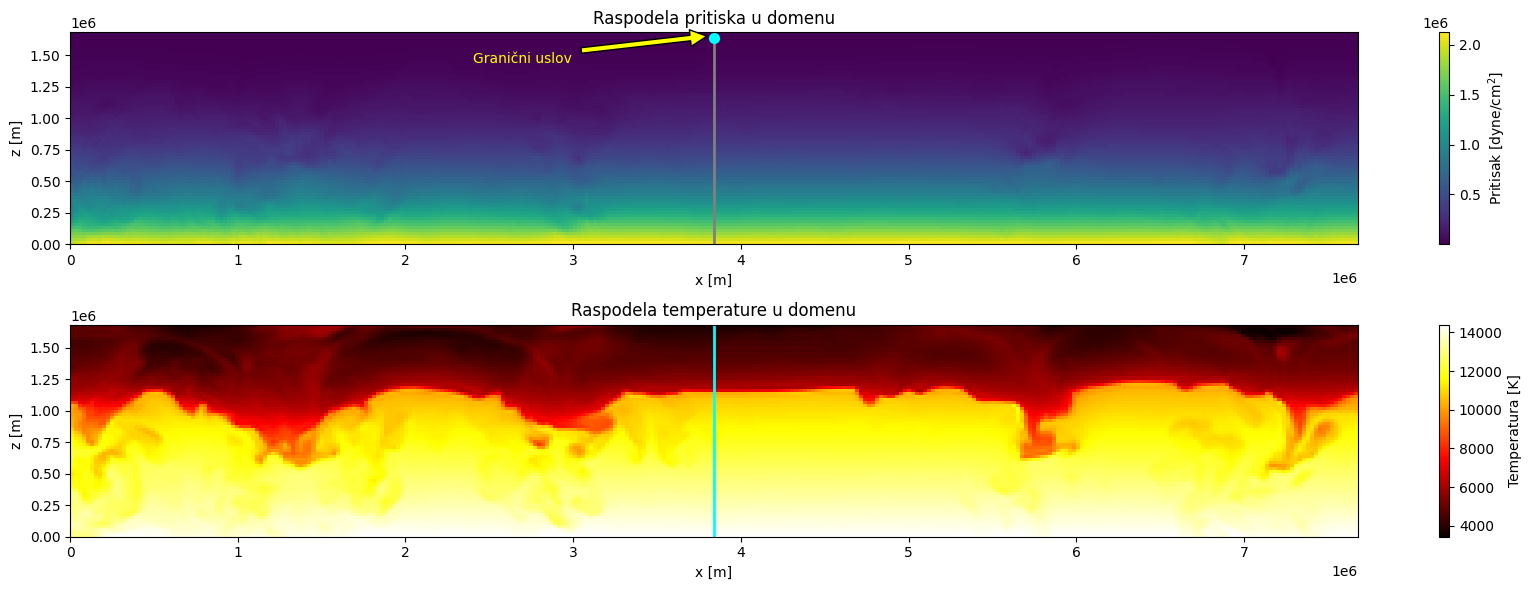

In [3]:
pixel_to_m = 24000  # 1 pixel = 24000 m
extent = [0, data_raw[0].data[0, 0:320, 0, :].shape[0]*pixel_to_m, 0, data_raw[0].data[0, :, 0, :].shape[1]*pixel_to_m]  # [x_min, x_max, z_min, z_max]


fig, axes = plt.subplots(2, 1, figsize=(17, 6))  # 2 reda, 1 kolona

# -------------------------
# Pritisak 
# -------------------------
ax = axes[0]
im = ax.imshow(
    data_raw[0].data[1, 0:320, 0, :].transpose(1, 0),  # transponujemo da z ide gore-dole
    cmap='viridis',
    origin='lower',
    extent=extent,
    aspect='auto'
)
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
plt.colorbar(im, ax=ax, label="Pritisak [dyne/cm$^2$]")

rect = patches.Rectangle(
    (160*pixel_to_m, 0),   # x_min, z_min
    0,         # width = 170 - 160
    70*pixel_to_m,         # height = 70
    linewidth=2,
    edgecolor='gray',
    facecolor='none'
)
ax.add_patch(rect)

ax.scatter(160*pixel_to_m, 68*pixel_to_m, color='cyan', linewidth=2)

ax.annotate('Granični uslov', xy=(160*pixel_to_m, 69*pixel_to_m), xytext=(100*pixel_to_m, 60*pixel_to_m),
            arrowprops=dict(facecolor='yellow', shrink=0.05), color='yellow')
ax.set_title('Raspodela pritiska u domenu')

# -------------------------
# Temperatura
# -------------------------
ax = axes[1]
im = ax.imshow(
    data_raw[0].data[0, 0:320, 0, :].transpose(1, 0),  # promenjeno
    cmap='hot',
    origin='lower',
    extent=extent,
    aspect='auto'
)
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
plt.colorbar(im, ax=ax, label="Temperatura [K]")

# Rectangle region of interest
rect = patches.Rectangle(
    (160*pixel_to_m, 0),
    0,
    70*pixel_to_m,
    linewidth=2,
    edgecolor='cyan',
    facecolor='none'
)
ax.add_patch(rect)
ax.set_title('Raspodela temperature u domenu')


plt.tight_layout()
plt.show()


In [4]:
data_1D = data_raw[0].data[:, 160, 0, :] # Ovime smo uklonili x i y osu, ostale su nam samo fizičke veličine koje zavise od z
print("data_1D shape =",data_1D.shape)

data_1D shape = (5, 70)


In [5]:
T_1D = data_1D[0] # Podaci 1D Temperature
P_1D = data_1D[1] # Podaci 1D Pritiska
   
z_min = 0         # metri
z_max = 70 * 24e3 # metri
z_sim = np.linspace(z_min, z_max, len(T_1D))

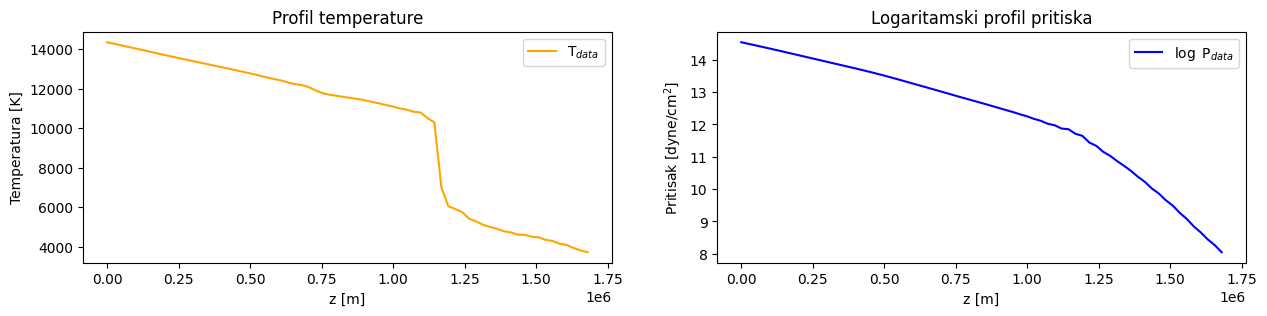

In [6]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 2, 1) 
plt.plot(z_sim, T_1D, label='T$_{data}$', color='orange')
plt.xlabel("z [m]")
plt.ylabel("Temperatura [K]")
plt.title("Profil temperature")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(z_sim, np.log(P_1D), label='$\log$ P$_{data}$', color='blue')
plt.xlabel("z [m]")
plt.ylabel("Pritisak [dyne/cm$^2$]")
plt.title("Logaritamski profil pritiska")
plt.legend()

plt.show()

In [7]:
# Fizičke konstante

m_p = 1.66053906660e-27
mu = 1.15

m_sr = mu * m_p                   # kg
k_b = 1.380649e-23                # J/K
g = 274.0                         # gravitaciono ubrzanje na Suncu - m/s^2


U sledećem koraku formiramo ulazne promenljive za PINN i prilagođavamo ih tako da budu pogodne za automatsku diferencijaciju i stabilno treniranje mreže.

Koordinata visine $z$ se najpre normalizuje deljenjem sa maksimalnom visinom domena $z_{max}$⁡. Normalizacija je važna jer neuronske mreže mnogo stabilnije uče kada su ulazi reda veličine $O(1)$, a ujedno se izbegavaju numerički problemi prilikom računanja gradijenata.

Nakon normalizacije, podaci se prebacuju u PyTorch tensor i oblikuju u kolonu dimenzije (N,1), što odgovara formatu ulaza neuronske mreže.

In [8]:
# Priprema podataka za treniranje PINN-a

Z_flat = torch.from_numpy(z_sim / z_max).float().reshape(-1, 1) # pravimo torch tensor i normalizujemo na [0, 1]
Z_dom = Z_flat.requires_grad_(True) # omogućavamo računanje gradijenata

print("Z_dom:", Z_dom.shape)

Z_top = torch.ones(1, 1)   # z = z_max / normalizovano na 1


Z_dom: torch.Size([70, 1])


U ovom koraku definišemo neuronsku mrežu koja predstavlja aproksimaciju nepoznatih fizičkih veličina u Physics-Informed Neural Network (PINN) pristupu. Mreža uči mapiranje između prostorne koordinate z i izlaznih fizičkih polja, pri čemu se fizička ograničenja nameću preko funkcije gubitka.

In [9]:
# Definicija PINN mreže

class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        layers = []
        sizes = [1] + [32] + [64] + [64] + [64] + [32] + [2]
        
        for i in range(len(sizes) - 1):                    # za svaki sloj
            layers.append(nn.Linear(sizes[i], sizes[i+1])) # linearna transformacija
            if i < len(sizes) - 2:                         # dodajem aktivaciju osim za izlazni sloj
                layers.append(nn.Tanh())
                
        self.net = nn.Sequential(*layers) 
        # Sequential kombinuje module u lanac

        for m in self.net:               # uzima svaki modul iz sekvencijalnog modela
            if isinstance(m, nn.Linear): # samo linerarni slojevi imaju tezine i bias
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias) # bias prvobitno postavljamo na nulu

    def forward(self, X):
        return self.net(X)

Nakon definicije arhitekture neuronske mreže, instanciramo PINN model i biramo algoritam za optimizaciju njegovih parametara.

In [10]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Pripremamo fizičke podatke koji se koriste za definisanje graničnih uslova, normalizaciju izlaza neuronske mreže i stabilno formulisanje funkcije gubitka u PINN modelu.

In [11]:
################################################################################################
# Ova vrednost se koristi za nametanje graničnog uslova na vrhu domena.
P_top = P_1D[-1] 
P_top_torch = torch.from_numpy(np.ascontiguousarray(P_top).astype(np.float32)).to(Z_dom.device)
logP_top_torch = torch.log(P_top_torch)

# np.ascontiguousarray() koristimo u slučaju da su podaci iz nekog razloga ne-redom u memoriji,
# napravimo kopiju koja je redom smeštena. To znači da su u memoriji svi elementi jedan za drugim, 
# što je važno za performanse pri radu sa Torch-om.

################################################################################################
# Za potrebe normalizacije izlaza neuronske mreže, određuje se maksimalna vrednost pritiska u domenu. 
# Maksimalni pritisak služi kao referentna skala, tako da neuronska mreža uči redukovanu veličinu
P_sim_torch = torch.from_numpy(np.ascontiguousarray(P_1D).astype(np.float32)).to(Z_dom.device)
P_max = torch.max(P_sim_torch)
logP_max = torch.log(P_max)

################################################################################################
# Na sličan način se priprema temperaturni profil. 
# Maksimalna temperatura u domenu koristi se kao normalizaciona konstanta.
T_max = np.max(T_1D)
T_sim = torch.from_numpy(np.ascontiguousarray(T_1D).astype(np.float32)).reshape(-1, 1).to(Z_dom.device)

U ovom koraku definišemo funkciju gubitka Physics-Informed Neural Network (PINN) modela. Ukupan gubitak se sastoji iz tri komponente: reziduala parcijalne diferencijalne jednačine (PDE), uslova saglasnosti sa temperaturnim podacima i graničnog uslova na vrhu domena.

Ukupna funkcija gubitka definiše se kao zbir doprinosa iz unutrašnjosti domena i graničnih uslova:
\begin{equation}
\mathcal{L} = \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{BC}} ,
\notag
\end{equation}

Gubitak na podacima forsira slaganje predikcije neuronske mreže sa poznatim temperaturnim profilom i definiše se kao
\begin{equation}
\mathcal{L}_{\mathrm{data}} =
\left\| T_{\mathrm{NN}}(z) - T_{\mathrm{data}}(z) \right\|^2 ,
\notag
\end{equation}
čime se osigurava da neuronska mreža reprodukuje dostupne temperaturne podatke duž celog domena.

PDE gubitak nameće uslov hidrostatčke ravnoteže na predviđeni pritisak. U logaritamskom zapisu, hidrostatčka jednačina ima oblik
\begin{equation}
\frac{d \log P}{dz} + \frac{g \mu m_p}{k_B T} = 0 ,
\notag
\end{equation}
pa se odgovarajući rezidual u PINN okviru definiše kao

\begin{equation}
\mathcal{L}_{\mathrm{PDE}} =\left\|\frac{d \log P_{\mathrm{NN}}}{dz}+ \frac{g \mu m_p}{k_B T_{\mathrm{data}}}\right\|^2 .
\notag
\end{equation}

Dodatno, poznata vrednost pritiska na gornjoj granici domena uvodi se kroz poseban granični gubitak
\begin{equation}
\mathcal{L}_{\mathrm{BC}} =
\left\|
\log P_{\mathrm{NN}}(z_{\max}) - \log P_{\mathrm{top}}
\right\|^2 ,
\notag
\end{equation}
čime se obezbeđuje da rešenje neuronske mreže zadovoljava granični uslov nezavisno od ponašanja u unutrašnjosti domena.

Na ovaj način, minimizacijom ukupne funkcije gubitka neuronska mreža istovremeno uči da reprodukuje poznati temperaturni profil, zadovolji jednačinu hidrostatčke ravnoteže i ispuni zadati granični uslov za pritisak.


In [12]:

def pinn_loss():

    # NN output
    Y = model(Z_dom)
    logp_reduced = Y[:, 0:1]              
    logp = logp_reduced + logP_max

    T_reduced = Y[:, 1:2]
    T = T_reduced * T_max

    grads = torch.autograd.grad(
        logp, Z_dom,
        grad_outputs=torch.ones_like(logp),
        create_graph=True
    )[0]

    dlogp_dz = grads[:, 0:1]

    # --------------------
    # Skala visine u normalizovanom obliku
    # --------------------
    H = (k_b * T_sim) / (m_sr * g)         # u metrima
    H_norm = H / z_max                     # normalizovano

    # --------------------
    # PDE rezidual u normalizovanom obliku 
    # --------------------
    Rez_1 = dlogp_dz + 1 / H_norm

    # --------------------
    # Temperaturni rezidual
    # --------------------
    Rez_3 = (T - T_sim) / T_max

    # --------------------
    # Granični uslov (VRH DOMENA)
    # --------------------
    logP_top_pred = model(Z_top)[:, 0:1]
    Rez_bc = (logP_top_pred + logP_max) - logP_top_torch

    # --------------------
    # Gubici skalarni
    # --------------------
    L_pde_1 = 1 * Rez_1.pow(2).mean()
    L_3 = 1 * Rez_3.pow(2).mean()
    L_bc  = 1 * Rez_bc.pow(2).mean()

    total_loss = L_pde_1 + L_bc + L_3

    return total_loss, L_pde_1, L_bc, L_3


Vršimo treniranje neuronske mreže. Tokom svakog epoha računa se ukupni gubitak PINN modela i prilagođavaju se težine mreže kako bi mreža istovremeno zadovoljila PDE rezidual, temperaturne podatke i granični uslov.

In [13]:
history = {
    "epoch": [],
    "loss_total": [],
    "loss_dlogp_dz": [],
    "loss_T": [],
    "bc_p": [],
}
#  desc="Training"
for epoch in trange(40000):
    optimizer.zero_grad() # moramo da resetujemo gradijente pre svakog koraka optimizacije

    loss, L1, L2, L3 = pinn_loss() # pozivamo funkciju gubitka
    loss.backward() # računamo gradijente po svim parametrima
    optimizer.step() # ažuriramo parametre modela
    
    history["loss_total"].append(loss.item())

    if epoch % 10000 == 0:
        history["epoch"].append(epoch)
        history["loss_dlogp_dz"].append(L1.item())
        history["loss_T"].append(L2.item())
        history["bc_p"].append(L3.item())
    
        print(f"\nEpoch {epoch}")
        print(f"  total loss   : {loss.item():.3e}")
        print(f"  dlogp/dz     : {L1.item():.3e}")
        print(f"  T loss       : {L2.item():.3e}")
        print(f"  BC logp      : {L3.item():.3e}")

  0%|          | 30/40000 [00:00<04:28, 149.10it/s]


Epoch 0
  total loss   : 1.179e+02
  dlogp/dz     : 7.600e+01
  T loss       : 4.157e+01
  BC logp      : 3.764e-01


 25%|██▌       | 10021/40000 [00:36<02:42, 184.55it/s]


Epoch 10000
  total loss   : 1.714e-03
  dlogp/dz     : 1.474e-03
  T loss       : 3.046e-08
  BC logp      : 2.398e-04


 50%|█████     | 20038/40000 [01:24<00:57, 348.32it/s]


Epoch 20000
  total loss   : 1.021e-03
  dlogp/dz     : 9.437e-04
  T loss       : 1.566e-07
  BC logp      : 7.725e-05


 75%|███████▌  | 30023/40000 [02:15<00:37, 268.69it/s]


Epoch 30000
  total loss   : 7.843e-04
  dlogp/dz     : 7.621e-04
  T loss       : 5.533e-09
  BC logp      : 2.220e-05


100%|██████████| 40000/40000 [03:06<00:00, 215.00it/s]


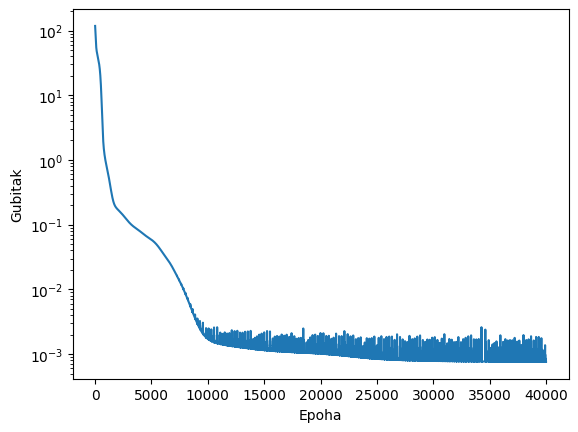

In [14]:
plt.semilogy(history["loss_total"])
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.show()

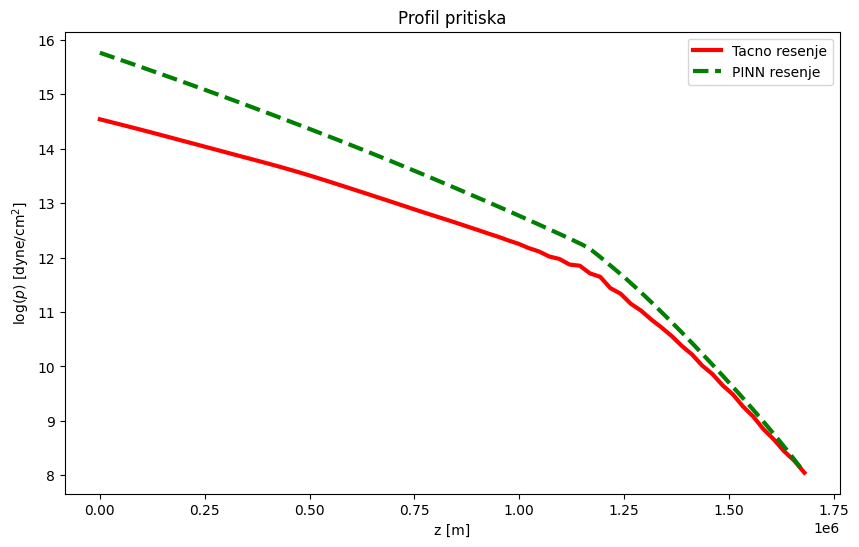

In [15]:
z_re = np.linspace(z_min, z_max, 150)
Z_re = torch.from_numpy(z_re / z_max).float().reshape(-1, 1).to(Z_dom.device)

p_pred = model(Z_re)[:,0] + logP_max
p_pred = p_pred.detach().numpy() # predikcija mreze

plt.figure(figsize = (10,6)) 
plt.plot(z_sim, np.log(P_1D), "red", label = "Tacno resenje", linewidth=3)
plt.plot(z_re, p_pred, "g--", label = "PINN resenje", linewidth=3)
plt.xlabel("z [m]")
plt.ylabel("$\log (p)$ [dyne/cm$^2$]")
plt.title("Profil pritiska")
plt.legend()
plt.show()


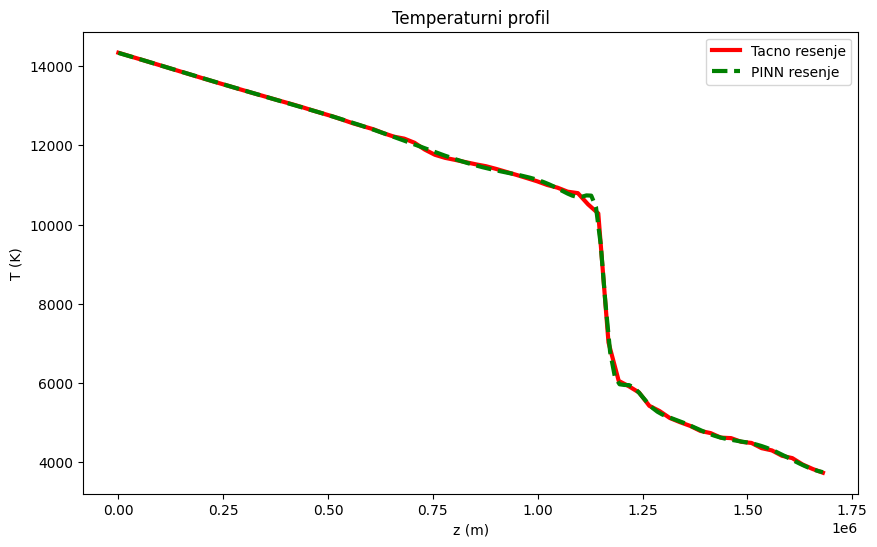

In [16]:
T_pred = model(Z_re)[:,1] * T_max
T_pred = T_pred.detach().numpy() # predikcija mreze

plt.figure(figsize = (10,6)) 
plt.plot(z_sim, T_1D, "red", label = "Tacno resenje", linewidth=3)
plt.plot(z_re, T_pred, "g--", label = "PINN resenje", linewidth=3)
plt.xlabel("z (m)")
plt.ylabel("T (K)")
plt.legend()
plt.title("Temperaturni profil")
plt.show()


***

### 2D Problem

U ovom zadatku razmatramo dvodimenzionalni atmosferski problem, u kome se temperatura i pritisak menjaju u prostoru.

**Podaci i ulazi:**
- `z_sim` – niz visina u domenu (m), koje predstavljaju tačke duž z-ose na kojima posmatramo promene atmosferskih veličina.
- `x_sim` –  niz horizontalnih koordinata u domenu (m), koje predstavljaju tačke duž x-ose na kojima posmatramo promene atmosferskih veličina.
- `T_2D` – poznati temperaturni podaci $T_{\mathrm{data}}(x, z)$.
- `P_top` – poznati podaci za pritisak na gornjoj granici $P_{\mathrm{data}}(x, z = z_{max})$.

**Zadatak neuronske mreže:**
- Aproksimacija funkcija:
  \begin{equation}
  T_{\mathrm{NN}}(x, z), \quad P_{\mathrm{NN}}(x, z)
  \notag
  \end{equation}

  koje zadovoljavaju fizički značajnu hidrostatčku ravnotežu:
  \begin{equation}
  \frac{d \log P (x, z)}{dz} + \frac{g \mu m_p}{k_B T(x, z)} = 0
  \notag
  \end{equation}

- Normalizacija vrednosti:
  - Visina `z` se normalizuje na [0,1] radi stabilnijeg treniranja.
  - Pritisak se koristi u logaritamskom obliku da bi numerički gradijenti bili stabilni (`logP`).
  - Temperatura se deli sa maksimalnom vrednošću (`T_max`) radi iste svrhe.

**Granični uslovi:**
- Pritisak na vrhu domena:
  \begin{equation}
  \log P_{\mathrm{NN}}(x, z_{\max}) = \log P_{\mathrm{top}}(x)
  \notag
  \end{equation}
  koji mreža mora da poštuje tokom treniranja.


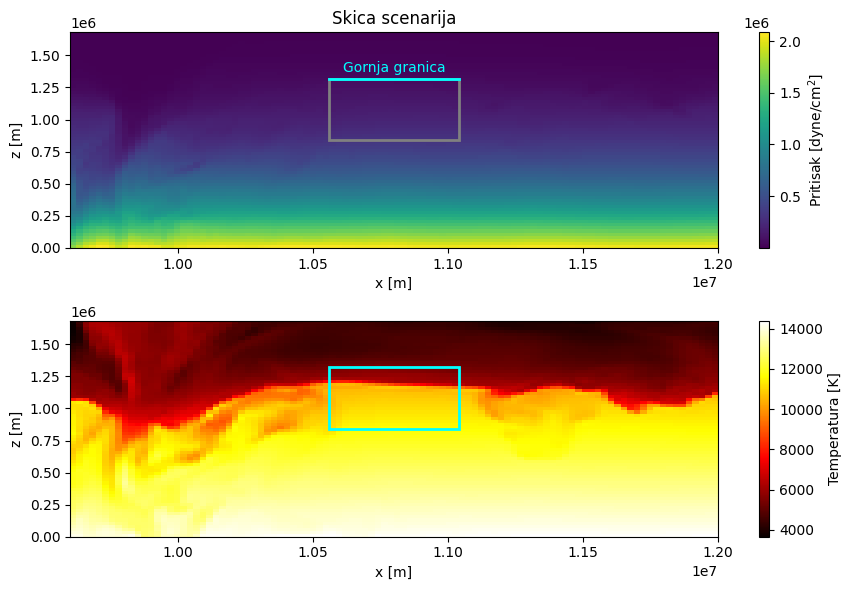

In [17]:
pixel_to_m = 24000  # 1 pixel = 24000 m
extent = [400*pixel_to_m, 500*pixel_to_m, 0, data_raw[0].data[0, :, 0, :].shape[1]*pixel_to_m]  # [x_min, x_max, z_min, z_max]


fig, axes = plt.subplots(2, 1, figsize=(9, 6))  # 2 reda, 1 kolona

# -------------------------
# Plot pritiska
# -------------------------
ax = axes[0]
im = ax.imshow(
    data_raw[0].data[1, 400:500, 0, :].transpose(1, 0),  # transponujemo da z ide gore-dole
    cmap='viridis',
    origin='lower',
    extent=extent,
    aspect='auto'
)
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
plt.colorbar(im, ax=ax, label="Pritisak [dyne/cm$^2$]")

# Region od interesa
rect = patches.Rectangle(
    (440*pixel_to_m, 35*pixel_to_m),   # x_min, z_min
    20*pixel_to_m,         # width = 170 - 160
    20*pixel_to_m,         # height = 70
    linewidth=2,
    edgecolor='gray',
    facecolor='none'
)
ax.add_patch(rect)

ax.annotate('Granični uslov', xy=(160*pixel_to_m, 69*pixel_to_m), xytext=(100*pixel_to_m, 60*pixel_to_m),
            arrowprops=dict(facecolor='yellow', shrink=0.05), color='yellow')
ax.set_title('Skica scenarija')

# Gornja granica pravougaonika
x0 = 440*pixel_to_m
x1 = x0 + 20*pixel_to_m
y_top = 35*pixel_to_m + 20*pixel_to_m

ax.plot([x0, x1], [y_top, y_top], color='cyan', linewidth=2)
ax.text((x0+x1)/2, y_top + 5e4, "Gornja granica", color='cyan', fontsize=10, ha='center')

ax.set_title('Skica scenarija')

# -------------------------
# Plot temperature
# -------------------------
ax = axes[1]
im = ax.imshow(
    data_raw[0].data[0, 400:500, 0, :].transpose(1, 0),
    cmap='hot',
    origin='lower',
    extent=extent,
    aspect='auto'
)
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
plt.colorbar(im, ax=ax, label="Temperatura [K]")

# Region od interesa
rect = patches.Rectangle(
    (440*pixel_to_m, 35*pixel_to_m),
    20*pixel_to_m,       
    20*pixel_to_m,        
    linewidth=2,
    edgecolor='cyan',
    facecolor='none'
)
ax.add_patch(rect)


plt.tight_layout()
plt.show()


In [18]:
data_2D = data_raw[0].data[:, 440:460, 0, 35:55] 
    
print("data_2D shape =",data_2D.shape)  

data_2D shape = (5, 20, 20)


In [19]:
T_2D = data_2D[0, :, :]
P_2D = data_2D[1, :, :]

print("Pritisak i temperatura su dimenzija:", np.shape(T_2D))

Pritisak i temperatura su dimenzija: (20, 20)


Jedino što je drugačije ovde, naspram prethodnog primera jeste da sada imamo dva ulaza, s obzirom da radimo na 2D podacima.

In [ ]:
# Definicija PINN mreže

class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        layers = []
        sizes = [2] + [32] + [64] + [128] + 2*[256] + [128] + [64] + [32] + [2] # dodao *2 ovdje
        for i in range(len(sizes) - 1):            # za svaki sloj
            layers.append(nn.Linear(sizes[i], sizes[i+1])) # linearna transformacija
            if i < len(sizes) - 2:                         # dodajem aktivaciju osim za izlazni sloj
                layers.append(nn.Tanh())
                
        self.net = nn.Sequential(*layers) 
        # Sequential kombinuje module u lanac

        for m in self.net:               # uzima svaki modul iz sekvencijalnog modela
            if isinstance(m, nn.Linear): # samo linerarni slojevi imaju tezine i bias
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        return self.net(X)

In [33]:
N_x = len(T_2D[: , 0]) # broj piksela u x
N_z = len(T_2D[0 , :]) # broj piksela u z

dx, dz = 24e3, 24e3  # fizicka vrednost piksela u metrima
z_max = N_z * dz            # m
x_max = N_x * dx            # m

Formiramo podatke za treniranje:

In [34]:
x_sim = np.linspace(0, N_x, N_x) * dx
z_sim = np.linspace(0, N_z, N_z) * dz
X, Z = np.meshgrid(x_sim, z_sim, indexing="ij")  # Pravimo 2D mrežu x i z koordinata (N_x, N_z)

# Pretvaramo nizove u torch tenzore i normalizujemo na [0, 1], 
# takođe ih reshapujemo u vektore dimenzija (N_x * N_z, 1)
X_flat = torch.from_numpy(X / x_max).float().reshape(-1, 1)
Z_flat = torch.from_numpy(Z / z_max).float().reshape(-1, 1)

# (N_x * N_z, 2) svaki red je jedna tačka u domenu
X_dom = torch.cat([X_flat, Z_flat], dim=1).requires_grad_(True) 

# Vrh domena (z = z_max)
x_top = torch.from_numpy(X[:, -1] / x_max).float().unsqueeze(1) 
# sve koordinate x na vrhu domena, 
# unsqueeze da bi dimenzije bile (N_x, 1) tj. dodajemo dimenziju
z_top = torch.ones_like(x_top) # z = z_max normalizovano na 1
X_top = torch.cat([x_top, z_top], dim=1) # (N_x, 2)

print("X_dom:", X_dom.shape)
print("X_top:", X_top.shape)

X_dom: torch.Size([400, 2])
X_top: torch.Size([20, 2])


In [ ]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.9) # dodao scheduler


In [61]:
################################################################################################
# Ova vrednost se koristi za nametanje graničnog uslova na vrhu domena.
P_top = P_2D[: , -1] 
P_top_torch = torch.from_numpy(np.ascontiguousarray(P_top).astype(np.float32)).to(X_dom.device)
logP_top_torch = torch.log(P_top_torch)

################################################################################################
# Za potrebe normalizacije izlaza neuronske mreže, određuje se maksimalna vrednost pritiska u domenu. 
# Maksimalni pritisak služi kao referentna skala, tako da neuronska mreža uči redukovanu veličinu
P_sim_torch = torch.from_numpy(np.ascontiguousarray(P_2D).astype(np.float32)).to(X_dom.device)
P_max = torch.max(P_sim_torch)   
logP_max = torch.log(P_max)

################################################################################################
# Na sličan način se priprema temperaturni profil. 
# Maksimalna temperatura u domenu koristi se kao normalizaciona konstanta.
T_max = np.max(T_2D)
T_sim_flat = torch.from_numpy(np.ascontiguousarray(T_2D).astype(np.float32)).reshape(-1, 1).to(X_dom.device)

In [69]:
def pinn_loss():

    # NN output
    Y = model(X_dom)
    logp_reduced = Y[:, 0:1]
    logp = logp_reduced + logP_max

    T_reduced = Y[:, 1:2]
    T = T_reduced * T_max

    grad = torch.autograd.grad(
        logp, X_dom,
        grad_outputs=torch.ones_like(logp),
        create_graph=True,
    )[0]

    dlogp_dz = grad[:, 1:2]

    # --------------------
    # Skala visine u normalizovanom obliku
    # --------------------
    H = (k_b * T_sim_flat) / (m_sr * g)         # u metrima
    H_norm = H / z_max  

    # --------------------
    # PDE rezidual u normalizovanom obliku 
    # --------------------
    Rez_1 = dlogp_dz + 1 / H_norm

    # --------------------
    # Temperaturni rezidual
    # --------------------
    Rez_3 = (T - T_sim_flat) / T_max

    # --------------------
    # Granični uslov (VRH DOMENA)
    # --------------------

    logP_top_pred = model(X_top)[:, 0:1]  # NN output = log(P/P0)
    Rez_bc = (logP_top_pred + logP_max) - logP_top_torch

    # --------------------
    # Skalarni gubici
    # --------------------
    L_pde_1 = 1.5 * Rez_1.pow(2).mean()
    L_3 = 1 * Rez_3.pow(2).mean()
    L_bc  = 1 * Rez_bc.pow(2).mean()



    total_loss = L_pde_1 + L_bc + L_3

    return total_loss, L_pde_1, L_bc, L_3

Treniranje mreže.

In [70]:
history = {
    "epoch": [],
    "loss_total": [],
    "loss_dlogp_dz": [],
    "loss_T": [],
    "bc_p": [],
}
#  desc="Training"
for epoch in trange(50000):
    optimizer.zero_grad()
    
    loss, L1, L3, L4 = pinn_loss()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    history["loss_total"].append(loss.item())
    history["loss_dlogp_dz"].append(L1.item()) # da bi se sacuvalo za svaki epoch, za plot
    history["loss_T"].append(L3.item())
    history["bc_p"].append(L4.item())

    if epoch % 10000 == 0:
        history["epoch"].append(epoch)
        history["loss_dlogp_dz"].append(L1.item())
        history["loss_T"].append(L3.item())
        history["bc_p"].append(L4.item())
    
        print(f"\nEpoch {epoch}")
        print(f"  total loss   : {loss.item():.3e}")
        print(f"  dlogp/dz     : {L1.item():.3e}")
        print(f"  T loss       : {L3.item():.3e}")
        print(f"  BC logp      : {L4.item():.3e}")

  0%|          | 5/50000 [00:00<34:04, 24.45it/s]  


Epoch 0
  total loss   : 1.923e-03
  dlogp/dz     : 6.294e-04
  T loss       : 1.028e-03
  BC logp      : 2.652e-04


 20%|██        | 10005/50000 [02:53<15:31, 42.93it/s]


Epoch 10000
  total loss   : 1.186e-03
  dlogp/dz     : 1.114e-04
  T loss       : 1.017e-03
  BC logp      : 5.827e-05


 40%|████      | 20009/50000 [06:14<09:38, 51.81it/s]

...


Epoch 30000
  total loss   : 1.081e-03
  dlogp/dz     : 3.798e-05
  T loss       : 1.016e-03
  BC logp      : 2.693e-05


 80%|████████  | 40010/50000 [12:07<02:43, 60.97it/s]


Epoch 40000
  total loss   : 1.075e-03
  dlogp/dz     : 3.571e-05
  T loss       : 1.016e-03
  BC logp      : 2.342e-05


 82%|████████▏ | 41051/50000 [12:26<02:42, 55.02it/s]


KeyboardInterrupt: 

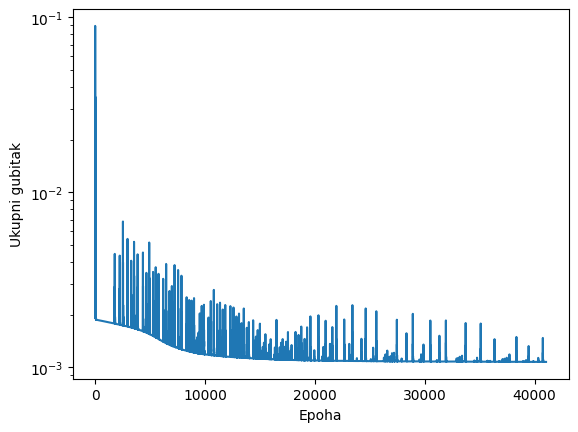

'\nplt.semilogy(history["loss_dlogp_dz"])\nplt.xlabel("Epoha")\nplt.ylabel("Gubitak")\nplt.show()\nplt.semilogy(history["loss_T"])\nplt.xlabel("Epoha")\nplt.ylabel("Gubitak")\nplt.show()\nplt.semilogy(history["bc_p"])\nplt.xlabel("Epoha")\nplt.ylabel("Gubitak")\nplt.show()\n'

In [71]:
plt.semilogy(history["loss_total"])
plt.xlabel("Epoha")
plt.ylabel("Ukupni gubitak")
plt.show()
"""
plt.semilogy(history["loss_dlogp_dz"])
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.show()
plt.semilogy(history["loss_T"])
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.show()
plt.semilogy(history["bc_p"])
plt.xlabel("Epoha")
plt.ylabel("Gubitak")
plt.show()
"""

In [72]:
# Predikcija temperature u 2D domenu
T_pred = model(X_dom)[:,1] * T_max
T_pred = T_pred.detach().numpy().reshape(N_x, N_z) # predikcija mreze
print("T_pred shape =", T_pred.shape)
# Računanje relativne greške
rel_err = (T_pred - T_2D) / T_2D
vmax_err = np.max(np.abs(rel_err))

T_pred shape = (20, 20)


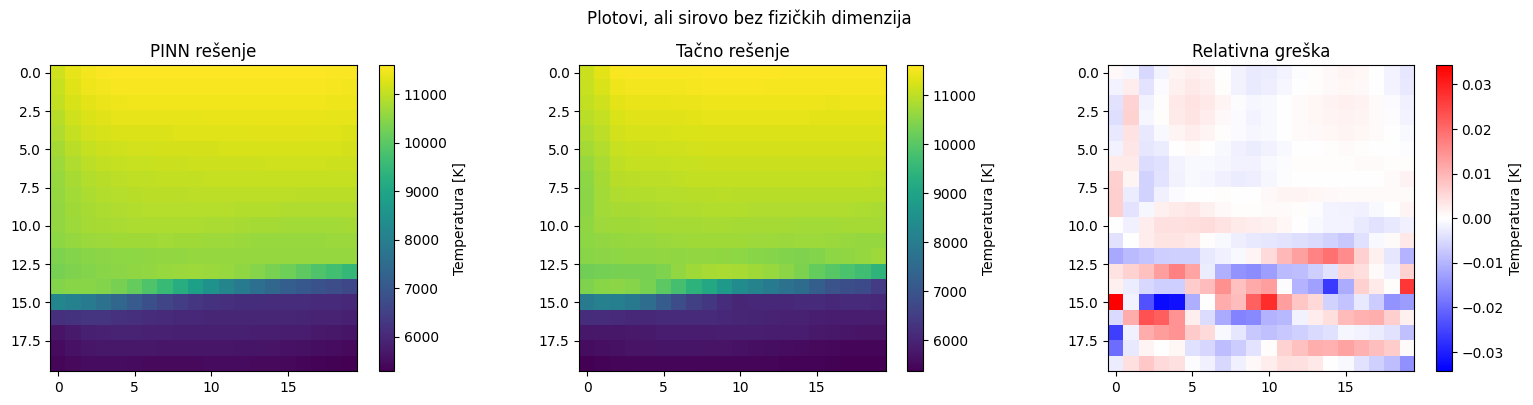

In [73]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)    
plt.imshow(T_pred.T)
plt.title("PINN rešenje")
plt.colorbar(label="Temperatura [K]")
plt.subplot(1, 3, 2)
plt.imshow(T_2D.T)
plt.title("Tačno rešenje")
plt.colorbar(label="Temperatura [K]")
plt.subplot(1, 3, 3)
T_rel = (T_pred - T_2D) / T_2D
plt.imshow(T_rel.T, vmin=-vmax_err, vmax=vmax_err, cmap='bwr')
plt.title("Relativna greška")
plt.colorbar(label="Temperatura [K]")
plt.suptitle("Plotovi, ali sirovo bez fizičkih dimenzija")
plt.tight_layout()
plt.show()    

Text(0.5, 1.0, 'Rel_err = (T_pred - T_sim) / T_sim')

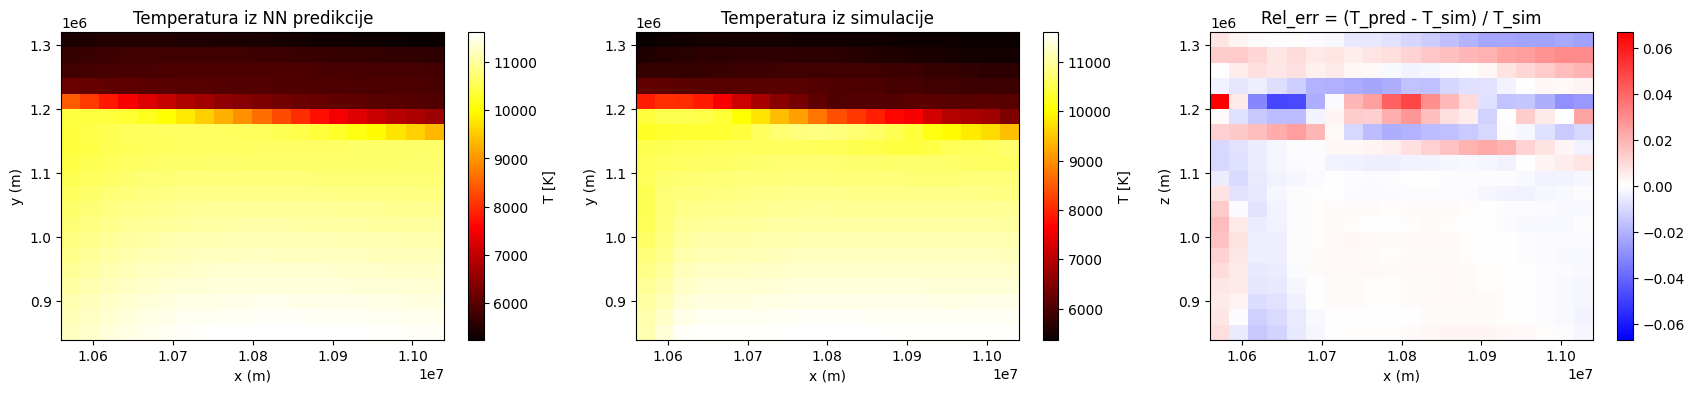

In [ ]:
# Grafički prikaz rezultata
extent = [440*pixel_to_m, 460*pixel_to_m, 35*pixel_to_m, 55*pixel_to_m]  # [x_min, x_max, z_min, z_max]

fig, ax = plt.subplots(1, 3, figsize = (21,4))
ax[0].imshow(T_pred.transpose(1,0), label = "NN prediction")
fig.colorbar(ax[0].imshow(T_pred.transpose(1,0), extent=extent, aspect='auto', origin='lower', cmap='hot'), label = "T [K]")
ax[0].set_title('Temperatura iz NN predikcije')
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('y (m)')

ax[1].imshow(T_2D.transpose(1,0))
fig.colorbar(ax[1].imshow(T_2D.transpose(1,0), extent=extent, aspect='auto', origin='lower', cmap='hot'), label = "T [K]")
ax[1].set_title('Temperatura iz simulacije')
ax[1].set_xlabel('x (m)')
ax[1].set_ylabel('y (m)')

ax[2].imshow(rel_err.T,vmin=-vmax_err,vmax= vmax_err)
ax[2].set_xlabel('x (m)')
ax[2].set_ylabel('z (m)')
fig.colorbar(ax[2].imshow(rel_err.T, extent=extent, vmin=-vmax_err, vmax= vmax_err, aspect='auto', origin='lower', cmap='bwr'))
ax[2].set_title('Rel_err = (T_pred - T_sim) / T_sim')

In [75]:
# Predikcija pritiska u 2D domenu
logP_pred_all = model(X_dom)[:,0] + logP_max
logP_pred_all = logP_pred_all.detach().numpy().reshape(N_x, N_z) # predikcija mreze

# Računanje minimalne i maksimalne vrednosti za kolorne mape
vmin = min(np.min(logP_pred_all), np.min(np.log(P_2D)))
vmax = max(np.max(logP_pred_all), np.max(np.log(P_2D)))

# Računanje relativne greške
rel_err = (logP_pred_all - np.log(P_2D)) / np.log(P_2D)
vmax_err = np.max(np.abs(rel_err))

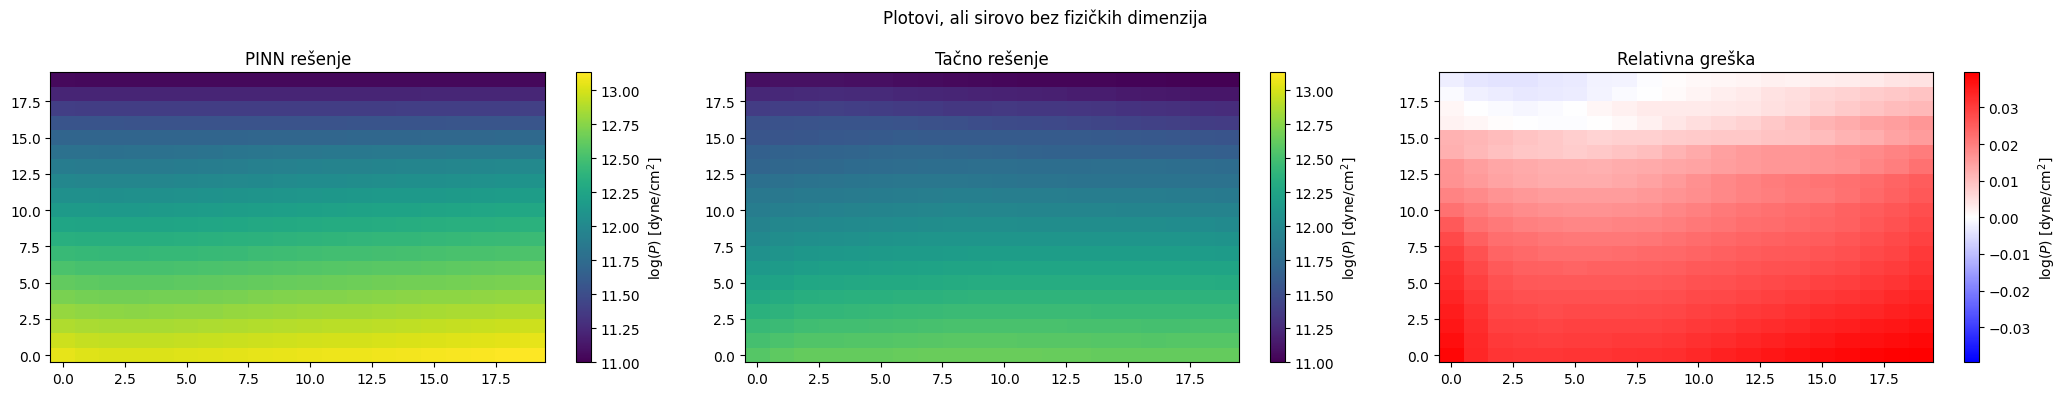

In [76]:
plt.figure(figsize=(21, 4)) 
plt.subplot(1, 3, 1)    
plt.imshow(logP_pred_all.T, vmin=vmin, vmax=vmax, aspect='auto', origin='lower', cmap='viridis')
plt.title("PINN rešenje")
plt.colorbar(label="$\log (P)$ [dyne/cm$^2$]")
plt.subplot(1, 3, 2)
plt.imshow(np.log(P_2D).T, vmin=vmin, vmax=vmax , aspect='auto', origin='lower', cmap='viridis')
plt.title("Tačno rešenje")
plt.colorbar(label="$\log (P)$ [dyne/cm$^2$]")
plt.subplot(1, 3, 3)
plt.imshow(rel_err.T, vmin=-vmax_err, vmax=vmax_err, cmap='bwr', aspect='auto', origin='lower')
plt.title("Relativna greška")
plt.colorbar(label="$\log (P)$ [dyne/cm$^2$]")
plt.suptitle("Plotovi, ali sirovo bez fizičkih dimenzija")
plt.tight_layout()
plt.show()

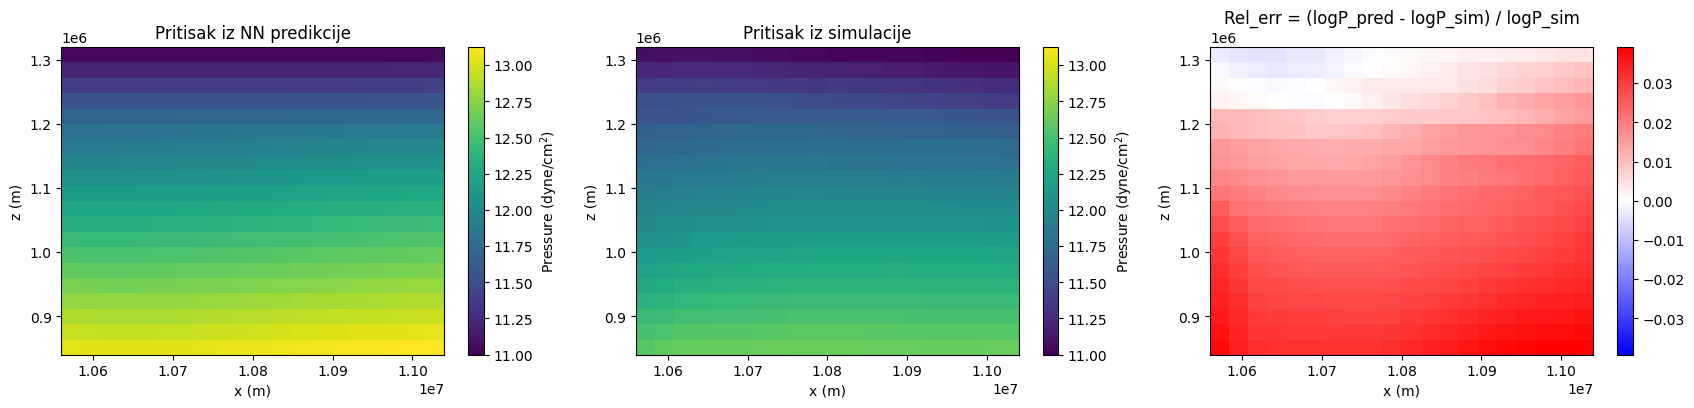

In [31]:
# Grafički prikaz rezultata
fig, ax = plt.subplots(1, 3, figsize=(21,4))
ax[0].imshow(logP_pred_all.transpose(1,0))
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('z (m)')
fig.colorbar(ax[0].imshow(logP_pred_all.transpose(1,0), extent=extent,vmin=vmin, vmax=vmax, aspect='auto', origin='lower', cmap='viridis'), label='Pressure (dyne/cm$^2$)')
ax[0].set_title('Pritisak iz NN predikcije')

ax[1].imshow(np.log(P_2D), vmin = vmin, vmax = vmax)
ax[1].set_xlabel('x (m)')
ax[1].set_ylabel('z (m)')
fig.colorbar(ax[1].imshow(np.log(P_2D).transpose(1,0), extent=extent,vmin=vmin, vmax=vmax, aspect='auto', origin='lower', cmap='viridis'), label='Pressure (dyne/cm$^2$)')
ax[1].set_title('Pritisak iz simulacije')

ax[2].imshow(rel_err.T,vmin=-vmax_err,vmax= vmax_err)
ax[2].set_xlabel('x (m)')
ax[2].set_ylabel('z (m)')
fig.colorbar(ax[2].imshow(rel_err.T, extent=extent, vmin=-vmax_err, vmax= vmax_err, aspect='auto', origin='lower', cmap='bwr'))
ax[2].set_title('Rel_err = (logP_pred - logP_sim) / logP_sim')


plt.show()

### Zaključak

Iz zadatih primera želimo istaći da je uz pomoć mašinskog učenja delimično moguće rekonstruisati polje pritiska u prethodno definisanom algoritmu, verujemo da pretpostavka konstantne molekulske mase nije dovoljno dobra aproksimacija za naše podatke.

U 1D problemu postiže se relativno bolje slaganje sa podacima od 2D slučaja, pokazuje da je to delimično posledica slučajno dobro izabrane konstantne srednje molekulske mase za date podatke koji su odabrani u prvom slučaju.

U 2D problemu, gde veličine zavise i od horizontalne koordinate, ova pretpostavka više nije dovoljna. Iako mreža uspešno prati temperaturu, dolazi do sistematskih odstupanja u pritisku, što ukazuje da konstantna molekulska masa ne može opisati ceo domen.

Za realističan 2D opis atmosfere potrebno je uvesti prostorno zavisnu molekulsku masu ili dodatne informacije, kao i da fizičke pretpostavke imaju ključan uticaj na uspešnost PINN modela.